## This notebook covers topic
Data visualization

preprocessing of Data

Model fitting using Scikit Learn

Model evaluation

Result analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import sklearn
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action="ignore", category= FutureWarning)

plt.rcParams["figure.figsize"] = [10,5]

https://seaborn.pydata.org/tutorial.html

## What is Seaborn?

Seaborn is a **Python data visualization library** built on top of **Matplotlib**.
It makes beautiful, informative statistical plots with **less code**.

### Why use Seaborn?
- Works directly with **Pandas DataFrames**
- Better default styles than Matplotlib
- Built-in support for **statistical plots**
- Very useful in **Data Science, AI, and Machine Learning**

### Seaborn vs Matplotlib
| Matplotlib | Seaborn |
|-----------|--------|
| Low-level | High-level |
| More code | Less code |
| Manual styling | Automatic styling |
| Basic plots | Statistical plots |

We will use the **Titanic dataset** to understand Seaborn visually.


## Loading the Dataset

We will load the Titanic dataset that you uploaded in Google Colab.
Pandas will read the CSV file and store it as a DataFrame.


In [ ]:
df = pd.read_csv("titanic_dataset.csv")

## Color Palette in Seaborn

A **color palette** is a collection of colors used in plots.

Seaborn palettes help to:
- Make plots visually attractive
- Distinguish categories clearly
- Improve readability in data analysis
- Follow good visualization practices in AI & ML

Seaborn provides **built-in palettes** and also allows **custom palettes**.


## Default Seaborn Color Palette

If you do not specify a palette, Seaborn uses its **default palette**.


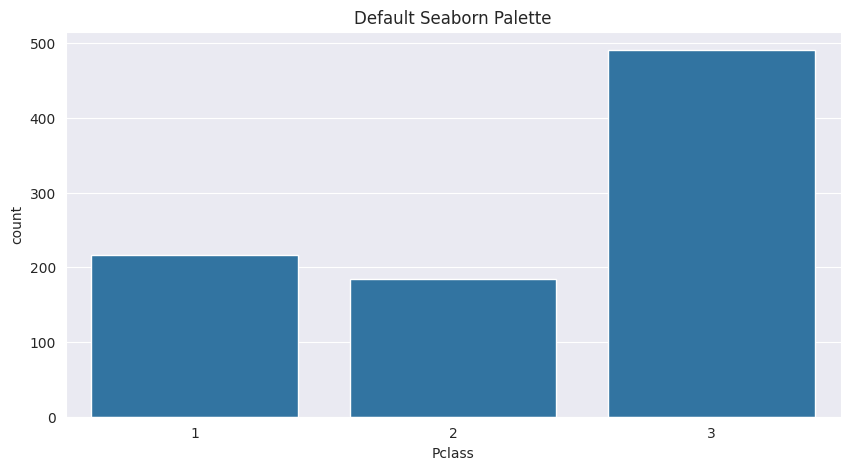

In [ ]:
sns.countplot(x="Pclass", data=df)
plt.title("Default Seaborn Palette")
plt.show()


## Viewing a Palette

We can display a palette using `sns.color_palette()`.


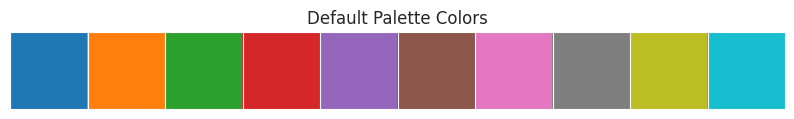

In [ ]:
sns.palplot(sns.color_palette())
plt.title("Default Palette Colors")
plt.show()

## Qualitative Color Palettes

Used for **categorical data** like:
- Gender
- Survival
- Passenger Class

Common qualitative palettes:
- deep (default)
- muted
- bright
- pastel
- dark
- colorblind (best for accessibility)


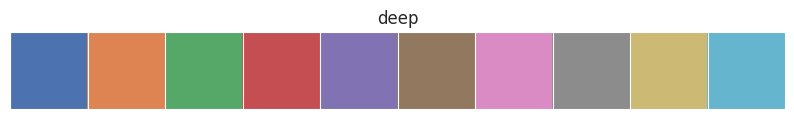

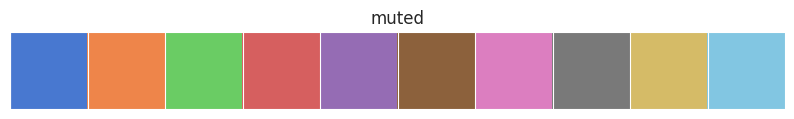

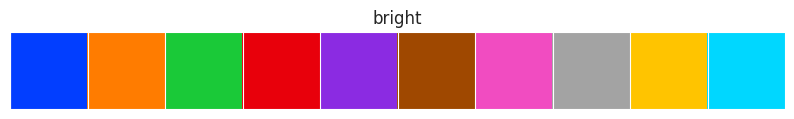

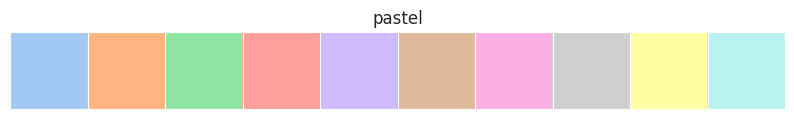

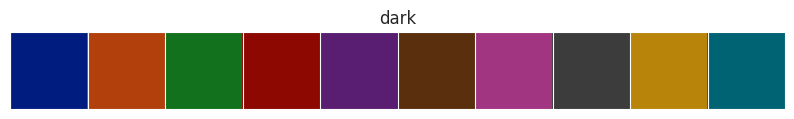

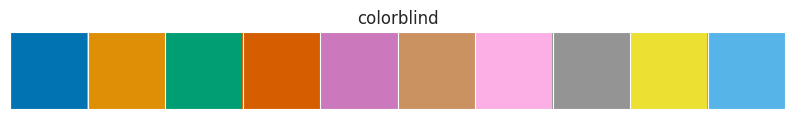

In [ ]:
palettes = ["deep", "muted", "bright", "pastel", "dark", "colorblind"]

for p in palettes:
    sns.palplot(sns.color_palette(p))
    plt.title(p)
    plt.show()


## Using Palette in a Plot

We use the `palette` parameter inside Seaborn plots.


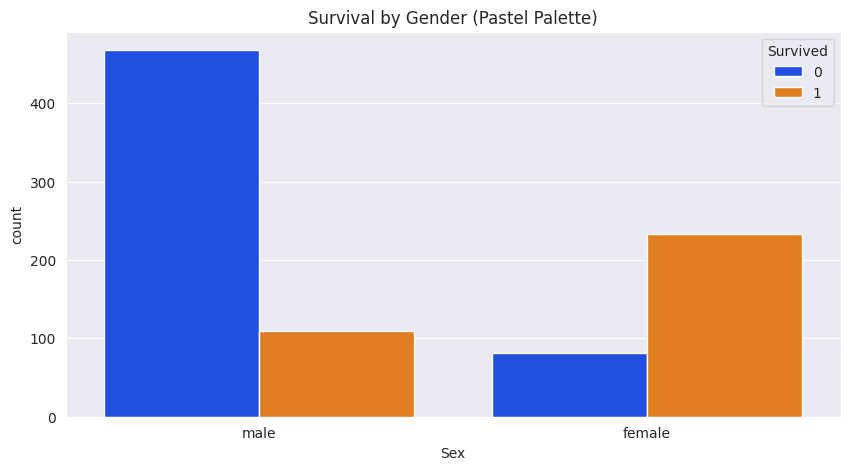

In [ ]:
sns.countplot(x="Sex", hue="Survived", data=df, palette="bright")
plt.title("Survival by Gender (Pastel Palette)")
plt.show()


## Sequential Palettes

Used when data has an **order** (low → high).

Examples:
- Age
- Fare
- Counts

Common sequential palettes:
- Blues
- Greens
- Oranges
- Purples
- viridis
- magma
- plasma


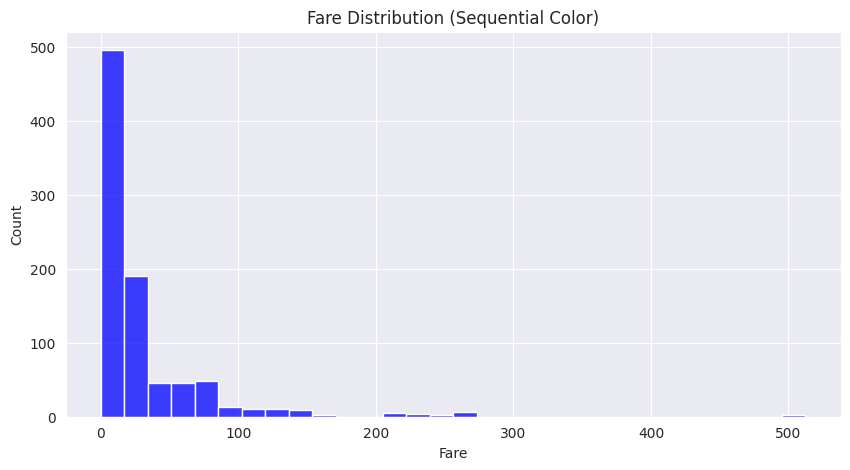

In [ ]:
sns.histplot(df["Fare"], bins=30, color="blue")
plt.title("Fare Distribution (Sequential Color)")
plt.show()


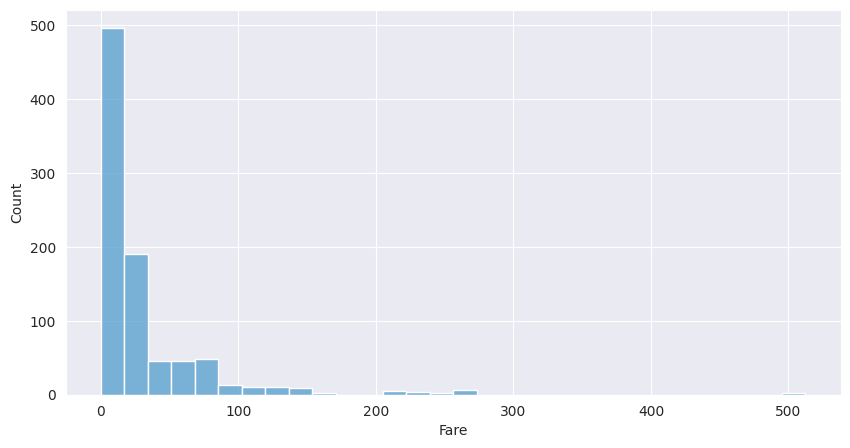

In [ ]:
sns.histplot(df["Fare"], bins=30, color=sns.color_palette("Blues")[3])
plt.show()


## Best Practices for Color Palettes

✔ Use **qualitative palettes** for categories  
✔ Use **sequential palettes** for numerical data  
✔ Use **diverging palettes** for correlations  
✔ Prefer **colorblind** palette for accessibility  
✔ Do NOT use too many colors  


## Understanding the Dataset

Before plotting, we must understand:
- Column names
- Data types
- Missing values

This is an **important habit in AI & ML projects**.


In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.shape

(891, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Seaborn Themes (Styles)

Seaborn provides built-in themes:
- darkgrid (default)
- whitegrid
- dark
- white
- ticks

Themes control background, grid, and aesthetics.


In [ ]:
sns.set_style("darkgrid")

#Plots

### 1. Count Plot

A **count plot** shows the number of observations in each category.

Example questions:
- How many males vs females?
- How many survived vs not survived?

This is VERY common in ML data analysis.


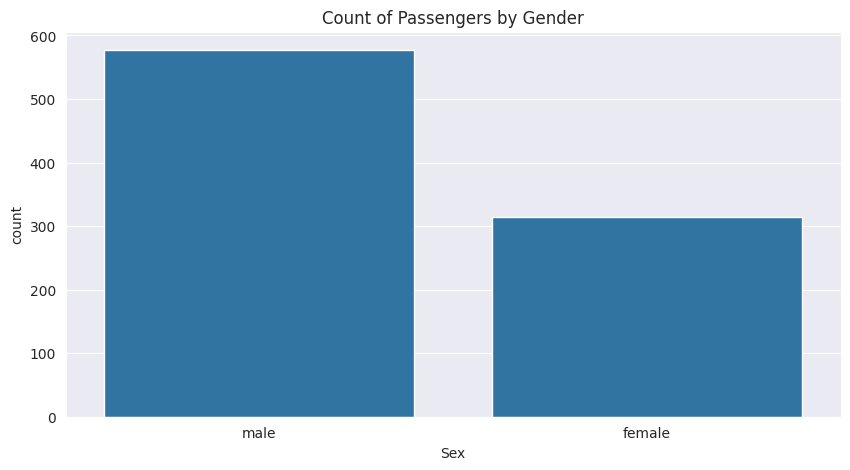

In [ ]:
sns.countplot(x="Sex", data=df)
plt.title("Count of Passengers by Gender")
plt.show()

## Count Plot with Hue

`hue` allows comparison using another category.

Example:
- Male vs Female survival


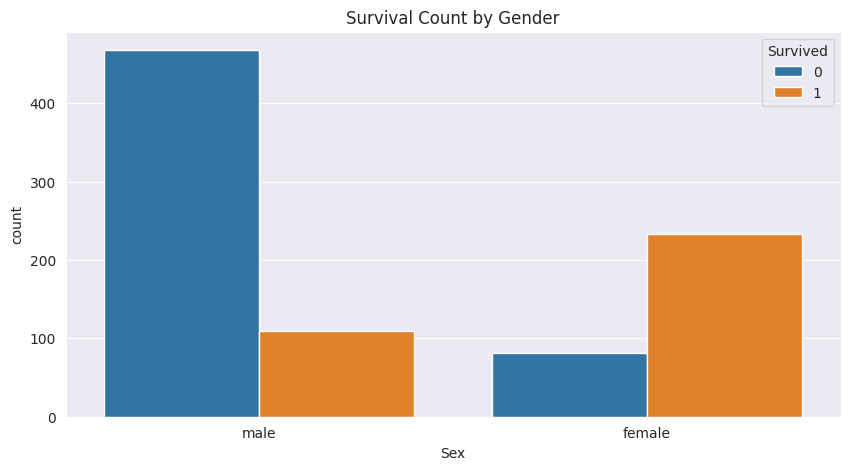

In [ ]:
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival Count by Gender")
plt.show()


##2. Distribution plot

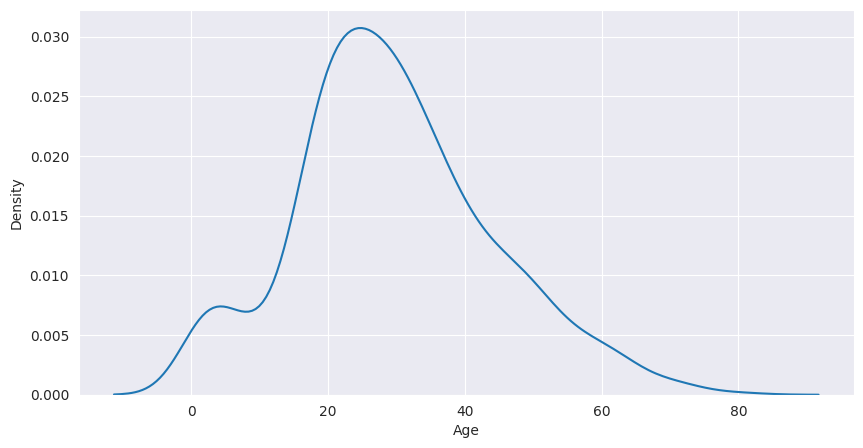

In [ ]:
sns.distplot(df["Age"], hist=False)
plt.show()

##2.1 Histogram

A histogram shows the **distribution** of numerical data.

Example:
- Distribution of passenger age
- Are most passengers young or old?


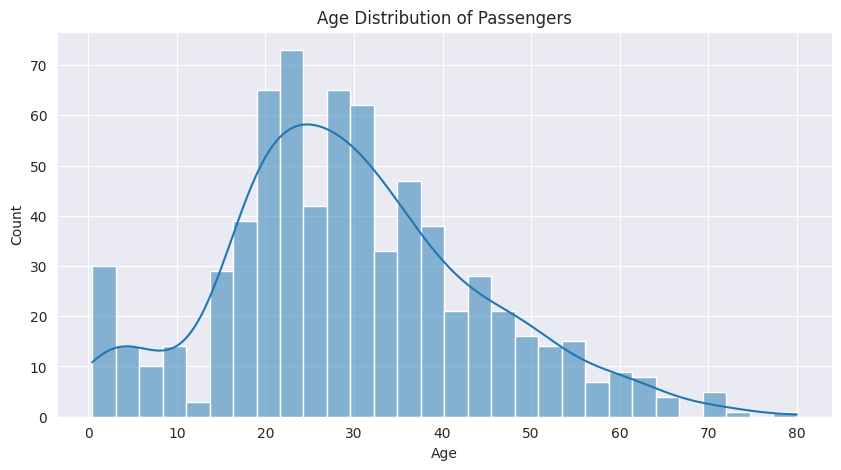

In [ ]:
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution of Passengers")
plt.show()

##3. Categorical Plot

##3.1 Box Plot

Box plots show:
- Median
- Quartiles
- Outliers

Used heavily in **ML for detecting outliers**.


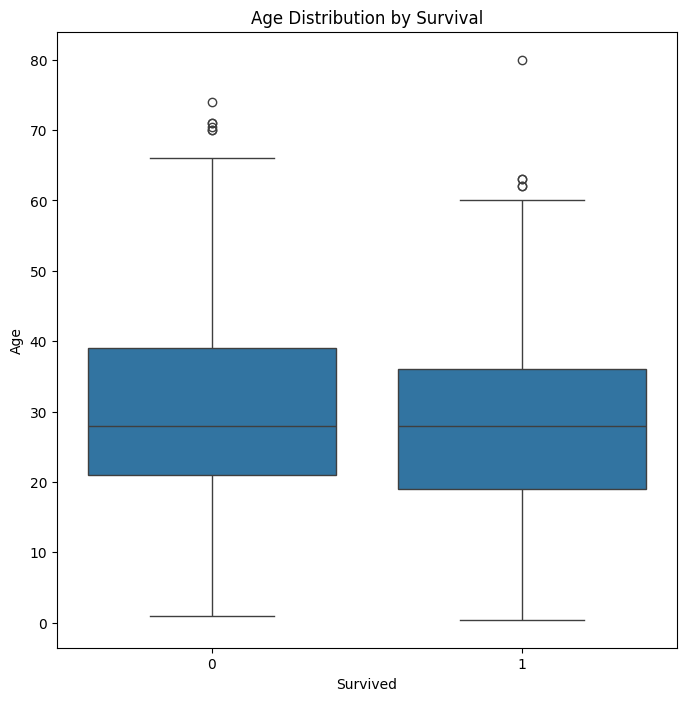

In [ ]:
plt.figure(figsize=(8,8))

sns.boxplot(x="Survived", y="Age", data=df)
plt.title("Age Distribution by Survival")
plt.show()

##3.2 Bar Plot

Bar plots show **aggregated values** like:
- Mean
- Median
- Sum

Seaborn calculates these automatically.


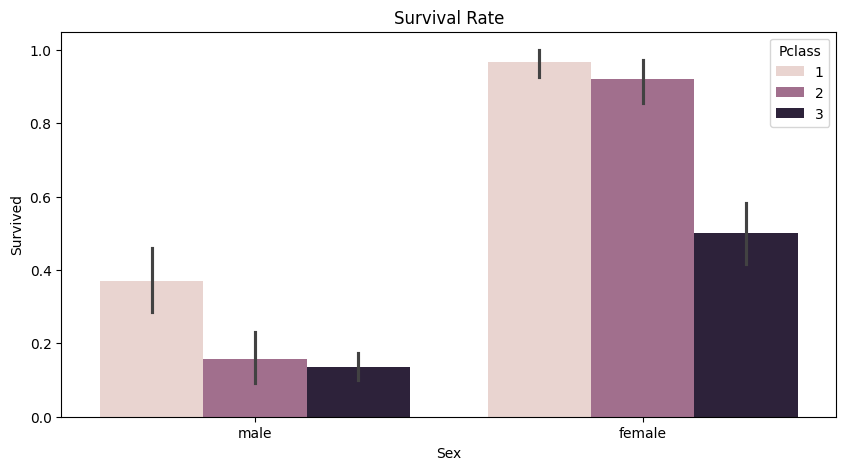

In [ ]:
sns.barplot(x="Sex", y="Survived",hue="Pclass", data=df)
plt.title("Survival Rate")
plt.show()

##3.3 stripplot

stripplot() shows individual data points for a categorical variable.

It is like a scatter plot but for categorical data.

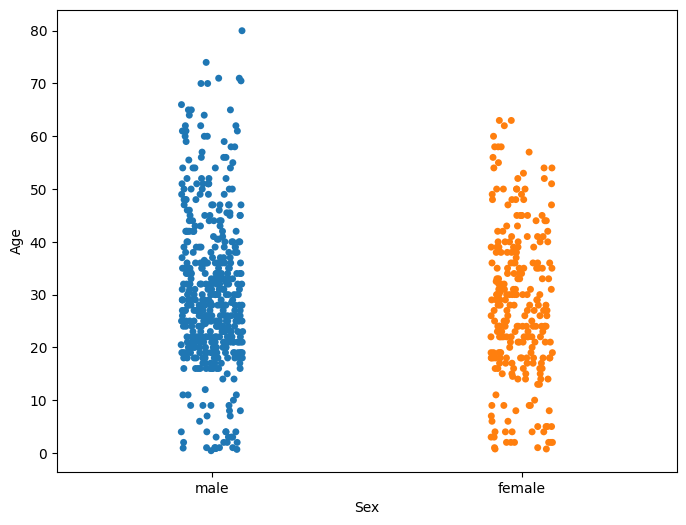

In [ ]:
plt.figure(figsize=(8,6))

sns.stripplot(
    data=df,
    x="Sex",
    y="Age",
    hue="Sex"
)

plt.show()


##3.4 swarmplot

swarmplot() is similar to stripplot but:

It adjusts points automatically  
Prevents overlapping

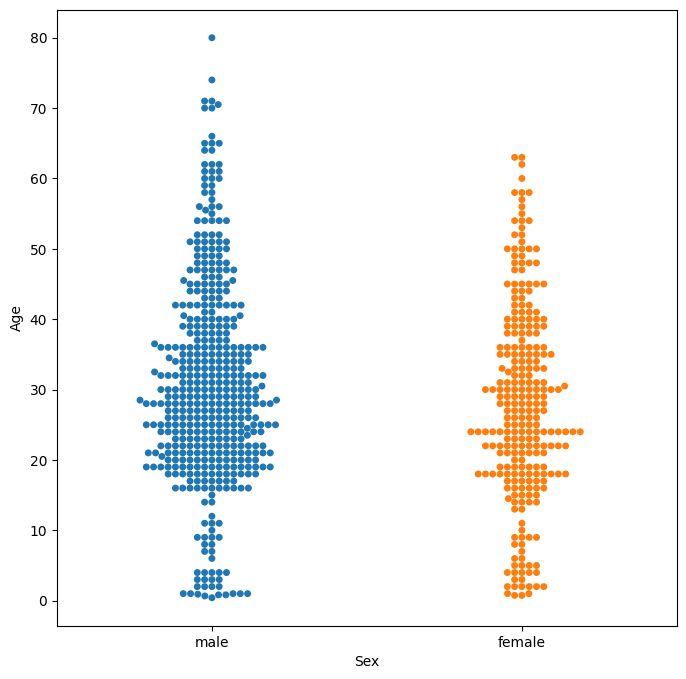

In [ ]:
plt.figure(figsize=(8,8))

sns.swarmplot(
data=df,
    x="Sex",
    y="Age",
    hue="Sex")

plt.show()


##3.5 Violinplot

violinplot() shows:

Distribution shape (like KDE)

Median and quartiles

Spread of data

It combines:  
* Boxplot + Density plot

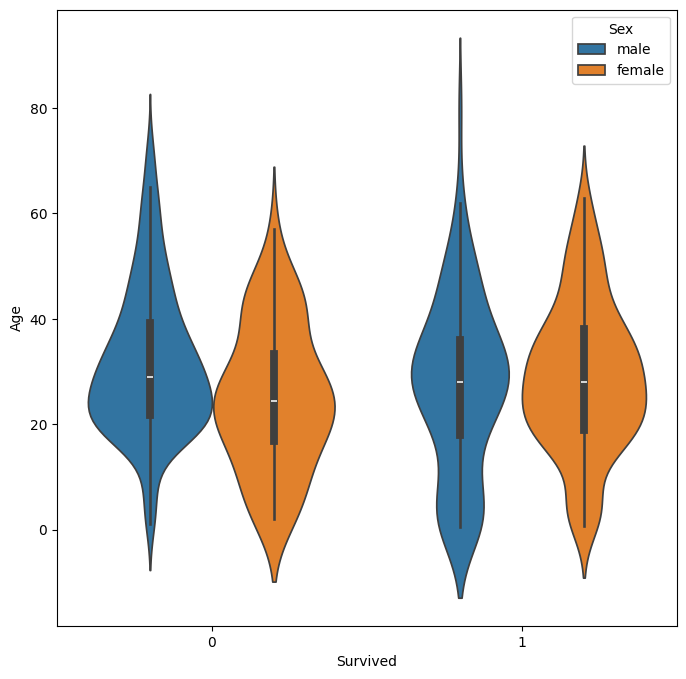

In [ ]:
plt.figure(figsize=(8,8))

sns.violinplot(
    data=df,
    x="Survived",
    y="Age",
    hue="Sex",
)

plt.show()


##3.6 pointplot

pointplot() shows:

Mean of numerical variable

Confidence interval (error bars)

It shows trend across categories.

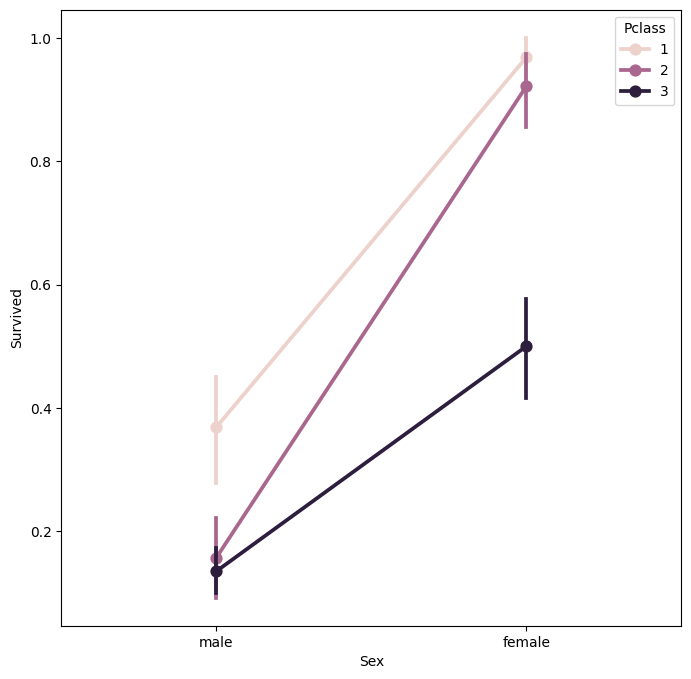

In [ ]:
plt.figure(figsize=(8,8))

sns.pointplot(
    data=df,
    x="Sex",
    y="Survived",
    hue="Pclass"
)

plt.show()


##4. Relational plots

##4.1 Relplot

relplot() is a figure-level function.
It is a high-level interface for drawing relational plots (scatter or line).

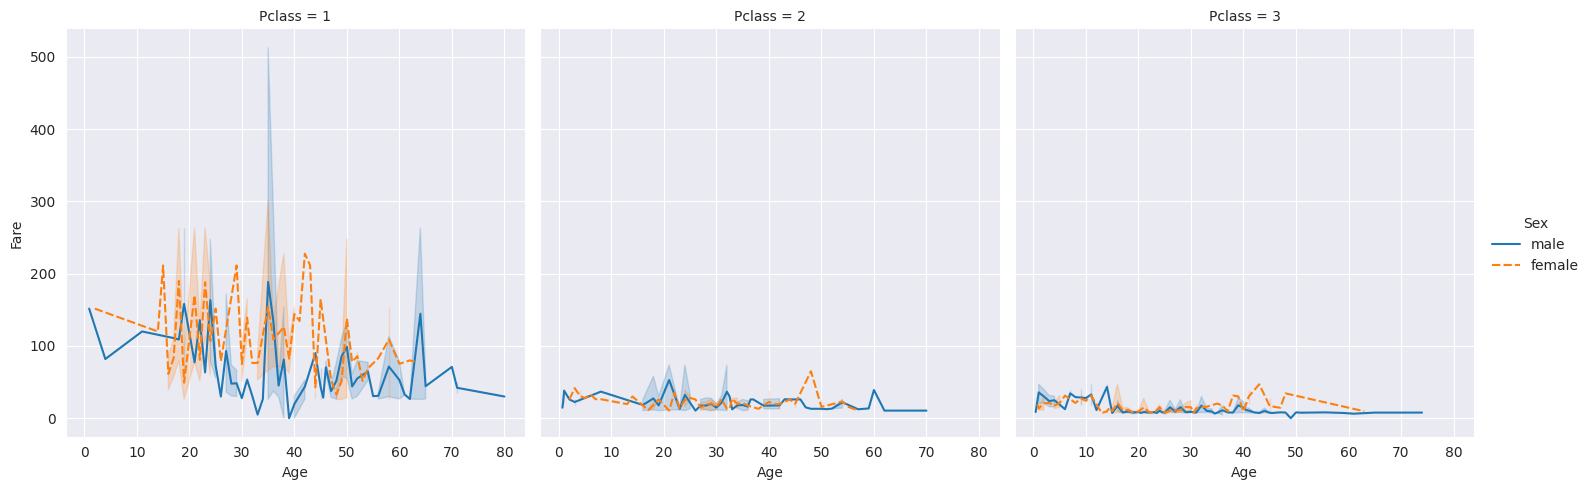

In [ ]:
sns.relplot(
    data=df,
    x="Age",
    y="Fare",
    col="Pclass",
    hue="Sex",
    style="Sex",
    kind="line"
)

plt.show()

##4.2 Scatter Plot

Scatter plots show relationships between two numerical variables.

Example:
- Age vs Fare


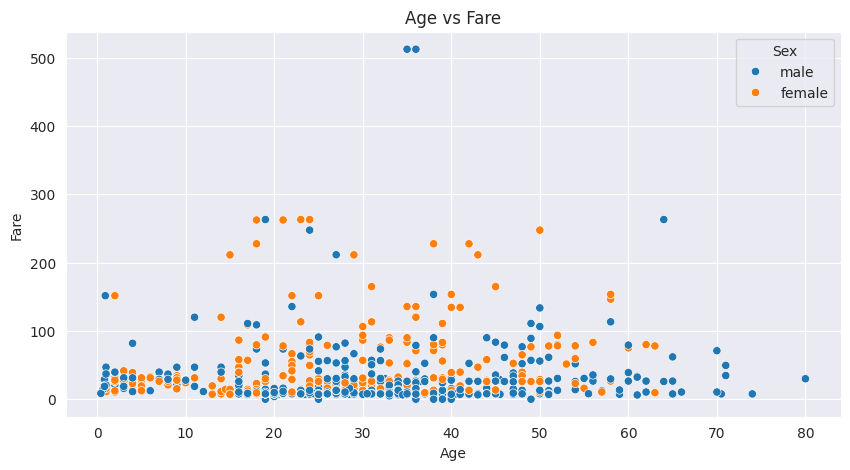

In [ ]:
sns.scatterplot(x="Age", y="Fare", hue="Sex", data=df)
plt.title("Age vs Fare")
plt.show()

##4.3 Lineplot

Used to show trend over a variable.

Usually good for:

Time series

Aggregated trends

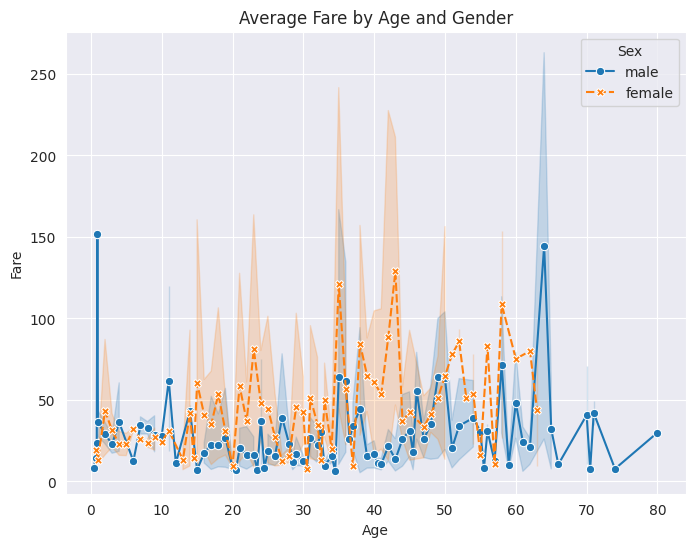

In [ ]:
plt.figure(figsize=(8,6))

sns.lineplot(
    data=df,
    x="Age",
    y="Fare",
    hue="Sex",
    style="Sex",
    markers=True
)

plt.title("Average Fare by Age and Gender")
plt.show()


##5. Matrix Plot

##5.1 Heatmap

A heatmap is used to visualize correlations.
Very important in **feature selection for ML**.


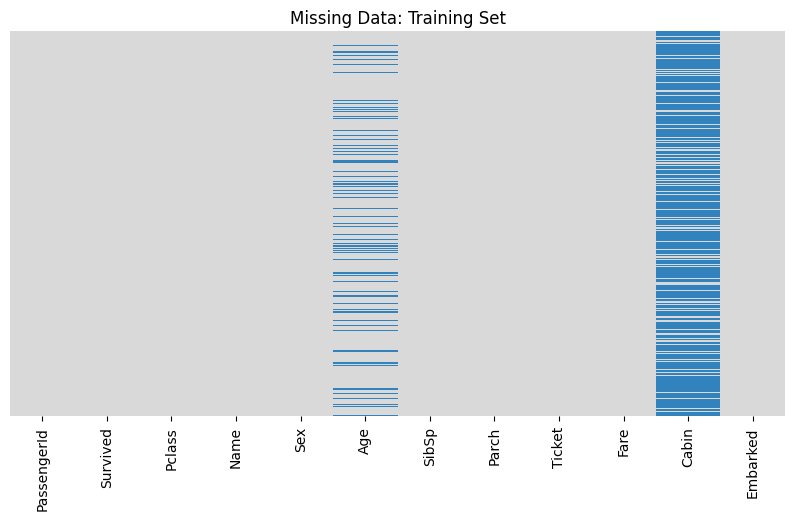

In [ ]:
sns.heatmap(df.isnull(), yticklabels=False,cbar=False, cmap="tab20c_r")
plt.title("Missing Data: Training Set")
plt.show()

##6. Regression Plots

##6.1 regplot

regplot():

Plots scatter plot

Adds regression line

Shows confidence interval (by default)

Is an axes-level function

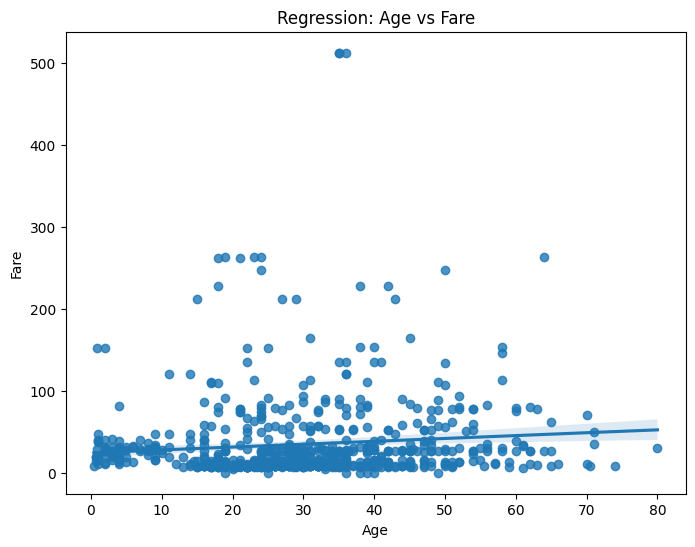

In [ ]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="Age",
    y="Fare"
)

plt.title("Regression: Age vs Fare")
plt.show()


##6.2 lmplot
Same purpose as regplot

But figure-level function

Supports hue, col, row

Creates multiple subplots easily

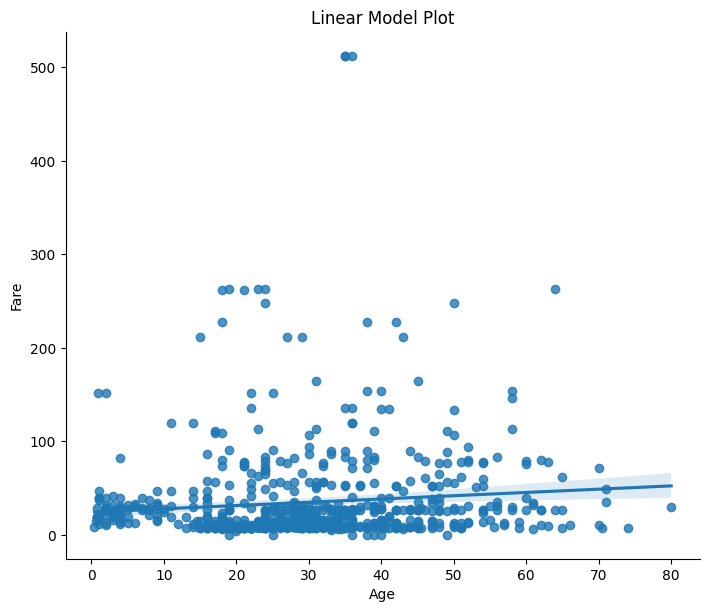

In [ ]:
sns.lmplot(
    data=df,
    x="Age",
    y="Fare",
    height=6,
    aspect=1.2
)

plt.title("Linear Model Plot")
plt.show()


#7. Multiplot grids

##7.2 FacetGrid

FacetGrid lets you create a grid of plots based on categorical variables.

It is very flexible.

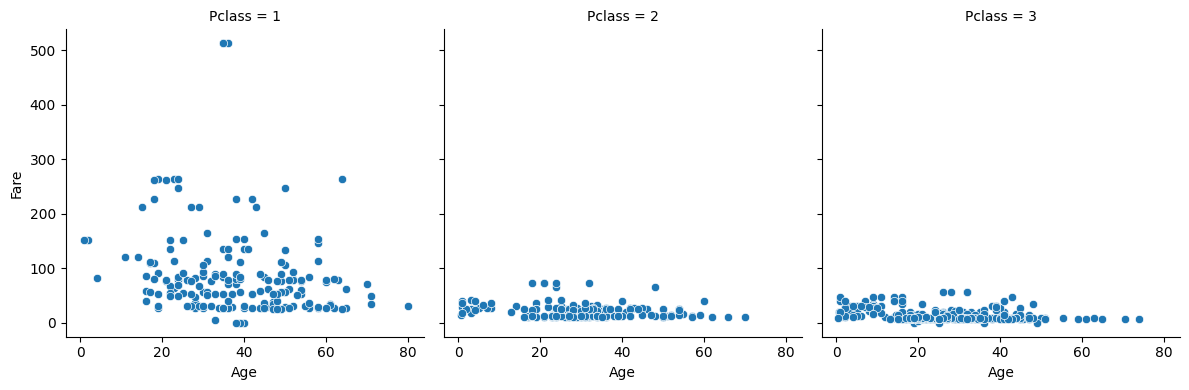

In [ ]:
g = sns.FacetGrid(df, col="Pclass", height=4)
g.map(sns.scatterplot, "Age", "Fare")

plt.show()


## Conclusion of Titanic Data Visualizations

After exploring multiple Seaborn plots on the Titanic dataset, we can summarize the key insights and learning outcomes.

---

### 1️⃣ Relationship Insights (Relational & Regression Plots)

Using:
- `scatterplot`
- `relplot`
- `regplot`
- `lmplot`

#### Observations:
- **Fare generally increases for higher passenger classes (Pclass 1).**
- There is **no strong linear relationship between Age and Fare**, but some trends exist.
- Gender-based differences appear when separating regression lines using `hue="Sex"`.

#### Learning:
Relational plots help us:
- Identify trends
- Detect correlations
- Compare subgroups visually

---

### 2️⃣ Categorical Plot Insights

Using:
- `stripplot`
- `swarmplot`
- `violinplot`
- `pointplot`

#### Observations:
- First-class passengers paid significantly higher fares.
- Fare distribution is highly skewed.
- Average fare differs clearly by passenger class.
- Gender differences become visible when split in violin or point plots.

#### Learning:
Categorical plots help us:
- Compare distributions across groups
- Analyze averages
- Understand data spread and density

---

### 3️⃣ Multi-Plot Grid Insights

Using:
- `FacetGrid`
- `pairplot`
- `jointplot`

#### Observations:
- Pairwise comparisons help detect hidden relationships.
- Faceting by class and gender makes patterns clearer.
- Joint plots show both relationship and distribution together.

#### Learning:
Multi-plot grids are powerful for:
- Exploratory Data Analysis (EDA)
- Comparing multiple variables at once
- Identifying patterns quickly

---

## Overall Data Insights from Titanic

- Passenger class strongly influenced fare.
- Gender shows visible grouping differences.
- Fare distribution is not normally distributed.
- Visualizations reveal patterns faster than raw numbers.

---

## Where to Explore More Graphs & Documentation

### Seaborn Official Documentation
https://seaborn.pydata.org/

### Seaborn Gallery (Examples)
https://seaborn.pydata.org/examples/index.html

### Matplotlib Documentation
https://matplotlib.org/stable/gallery/index.html

### Pandas Visualization Guide
https://pandas.pydata.org/docs/user_guide/visualization.html

### Kaggle Titanic Dataset
https://www.kaggle.com/competitions/titanic

---

## Final Beginner Advice

When doing EDA:

1. Start with basic distribution plots.
2. Move to relational plots.
3. Compare categories.
4. Use multi-plot grids for deeper insights.
5. Always interpret — not just plot.

---

 Data Visualization is not about making beautiful graphs.  
It is about **understanding data and telling a story with it.**


#Data preprocessing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import sklearn
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action="ignore", category= FutureWarning)

plt.rcParams["figure.figsize"] = [10,5]

In [ ]:
df = pd.read_csv("titanic_dataset.csv")

In [ ]:
df.shape

(891, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Missing Data

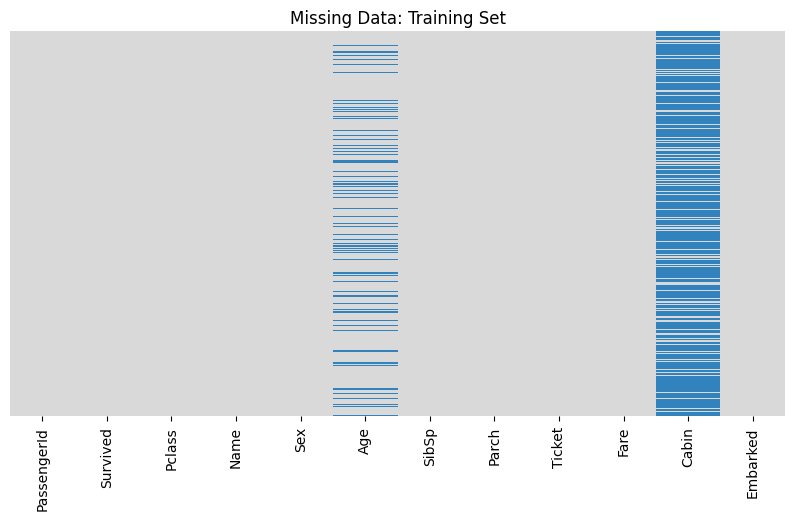

In [ ]:
sns.heatmap(df.isnull(), yticklabels=False,cbar=False, cmap="tab20c_r")
plt.title("Missing Data: Training Set")
plt.show()

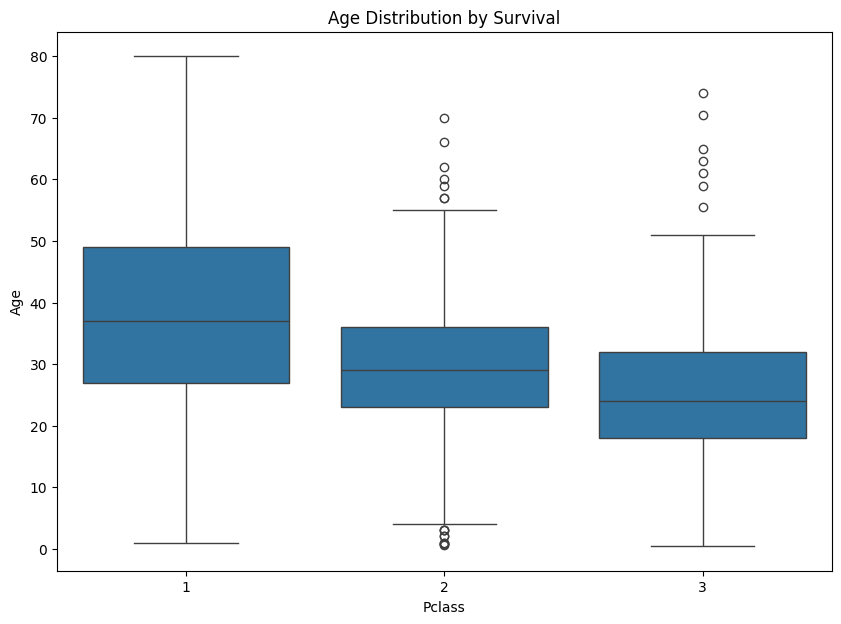

In [ ]:
plt.figure(figsize=(10,7))

sns.boxplot(x="Pclass", y="Age", data=df).set_title("Age by passenger class")
plt.title("Age Distribution by Survival")
plt.show()

In [ ]:
#imputation function
def impute_age(cols):
    Age= cols[0]
    Pclass = cols[1]

    if pd.isnull(Age):
        if Pclass == 1:
            return 37
        elif Pclass == 2:
            return 29
        else:
            return 24
    else:
        return Age
#Apply the function to the age column
df["Age"] = df[["Age","Pclass"]].apply(impute_age,axis = 1)


In [ ]:
#remove cabin feature
df.drop('Cabin',axis = 1, inplace=True)

In [ ]:
#remove rows with missing values
df.dropna(inplace=True)

In [ ]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,24.0,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [ ]:
#remove unnecessary columns
df.drop(["Name","Ticket"], axis = 1, inplace = True)

In [ ]:
#convert objects to category data type
objcat = ["Sex","Embarked"]
for colname in objcat:
    df[colname] = df[colname].astype('category')

In [ ]:
df

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,13.0000,S
887,888,1,1,female,19.0,0,0,30.0000,S
888,889,0,3,female,24.0,1,2,23.4500,S
889,890,1,1,male,26.0,0,0,30.0000,C


In [ ]:
#remove passengerId
df.drop("PassengerId", axis = 1, inplace = True)

In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000
mean,446.000000,0.382452,2.311586,29.019314,0.524184,0.382452,32.096681
std,256.998173,0.486260,0.834700,13.209814,1.103705,0.806761,49.697504
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,224.000000,0.000000,2.000000,22.000000,0.000000,0.000000,7.895800
50%,446.000000,0.000000,3.000000,26.000000,0.000000,0.000000,14.454200
75%,668.000000,1.000000,3.000000,36.500000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.shape

(889, 9)

In [ ]:
#identify categorical features
df.select_dtypes(["category"]).columns

Index(['Sex', 'Embarked'], dtype='object')

In [ ]:
sex = pd.get_dummies(df['Sex'], drop_first=True)
embarked = pd.get_dummies(df['Embarked'], drop_first=True)

In [ ]:
df = pd.concat([df,sex,embarked], axis = 1)
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,male,Q,S
0,1,0,3,male,22.0,1,0,7.2500,S,True,False,True
1,2,1,1,female,38.0,1,0,71.2833,C,False,False,False
2,3,1,3,female,26.0,0,0,7.9250,S,False,False,True
3,4,1,1,female,35.0,1,0,53.1000,S,False,False,True
4,5,0,3,male,35.0,0,0,8.0500,S,True,False,True


In [ ]:
#remove unnecessary columns
df.drop(["Sex","Embarked"], axis = 1, inplace = True)

In [ ]:
df.shape

(889, 10)

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,0,3,22.0,1,0,7.2500,True,False,True
1,2,1,1,38.0,1,0,71.2833,False,False,False
2,3,1,3,26.0,0,0,7.9250,False,False,True
3,4,1,1,35.0,1,0,53.1000,False,False,True
4,5,0,3,35.0,0,0,8.0500,True,False,True


Now train data is perfect for machine learning algorithims
* all the data is numeric
* everything is concatenated together

#Machine Learning

First step in ML pipeline:

Separate Feature Variables (x) and Target Variable (y)

In [ ]:
y = df["Survived"]
x = df.drop("Survived", axis=1)

In [ ]:
print("Features shape:", x.shape)
print("Target shape:", y.shape)


Features shape: (889, 9)
Target shape: (889,)


In [ ]:
from sklearn.preprocessing import StandardScaler
pre_process = StandardScaler().fit(x)
x_transform = pre_process.fit_transform(x)

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=101
)


In [ ]:
x_train

,PassengerId,Pclass,Age,SibSp,Parch,Fare,male,Q,S
307,308,1,17.0,1,0,108.9000,False,False,False
229,230,3,24.0,3,1,25.4667,False,False,True
82,83,3,24.0,0,0,7.7875,False,True,False
353,354,3,25.0,1,0,17.8000,True,False,True
707,708,1,42.0,0,0,26.2875,True,False,True
...,...,...,...,...,...,...,...,...,...
576,577,2,34.0,0,0,13.0000,False,False,True
840,841,3,20.0,0,0,7.9250,True,False,True
338,339,3,45.0,0,0,8.0500,True,False,True
524,525,3,24.0,0,0,7.2292,True,False,False


In [ ]:
x_test

,PassengerId,Pclass,Age,SibSp,Parch,Fare,male,Q,S
511,512,3,24.0,0,0,8.0500,True,False,True
613,614,3,24.0,0,0,7.7500,True,True,False
615,616,2,24.0,1,2,65.0000,False,False,True
337,338,1,41.0,0,0,134.5000,False,False,False
718,719,3,24.0,0,0,15.5000,True,True,False
...,...,...,...,...,...,...,...,...,...
155,156,1,51.0,0,1,61.3792,True,False,False
450,451,2,36.0,1,2,27.7500,True,False,True
756,757,3,28.0,0,0,7.7958,True,False,True
187,188,1,45.0,0,0,26.5500,True,False,True


In [ ]:
y_train

,Survived
307,1
229,0
82,1
353,0
707,1
...,...
576,1
840,0
338,1
524,0


In [ ]:
y_test

,Survived
511,0
613,0
615,1
337,1
718,0
...,...
155,0
450,0
756,0
187,1


#Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
logmodel = LogisticRegression()
logmodel.fit(x_train, y_train)


LogisticRegression()

In [ ]:
predictions = logmodel.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score

Log_accuracy = round(accuracy_score(y_test, predictions)*100,2)
print("Accuracy:", Log_accuracy)


Accuracy: 80.9


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)
print(cm)


[[99  8]
 [26 45]]


[[TN  FP]  
 [FN  TP]]

Where:

TN → Correctly predicted not survived

TP → Correctly predicted survived

FP → Predicted survived but actually not

FN → Predicted not survived but actually survived

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))


              precision    recall  f1-score   support

           0       0.79      0.93      0.85       107
           1       0.85      0.63      0.73        71

    accuracy                           0.81       178
   macro avg       0.82      0.78      0.79       178
weighted avg       0.81      0.81      0.80       178



#Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(x_train, y_train)


DecisionTreeClassifier(random_state=42)

In [ ]:
dtree_predictions = dtree.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score

Dt_accuracy = round(accuracy_score(y_test, dtree_predictions)*100,2)
print("Accuracy:", Dt_accuracy)


Accuracy: 78.65


#Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(random_state=42)
rfc.fit(x_train, y_train)


RandomForestClassifier(random_state=42)

In [ ]:
rfc_predictions = rfc.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score

rfc_accuracy = round(accuracy_score(y_test, rfc_predictions)*100,2)
print("Accuracy:", rfc_accuracy)


Accuracy: 85.39


#Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
gbc = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gbc.fit(x_train, y_train)

GradientBoostingClassifier(random_state=42)

In [ ]:
gbc_predictions = gbc.predict(x_test)


In [ ]:
from sklearn.metrics import accuracy_score

gbc_accuracy = round(accuracy_score(y_test, gbc_predictions)*100,2)
print("Accuracy:", gbc_accuracy)


Accuracy: 84.83


In [ ]:
print("Model rankings")
print("Logistic regression: ",Log_accuracy)
print("Decision Tree: ",Dt_accuracy)
print("Random Forest: ",rfc_accuracy)
print("Gradient Boosting: ",gbc_accuracy)

Model rankings
Logistic regression:  80.9
Decision Tree:  78.65
Random Forest:  85.39
Gradient Boosting:  84.83
